In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

sns.set_style('darkgrid')
color = sns.color_palette()
import matplotlib.mlab as mlab


In [2]:
conda install scikit-learn

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\ShimiDon\.conda\envs\python-starter

  added / updated specs:
    - scikit-learn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-2.0          |          52_msvc           6 KB
    ca-certificates-2026.8.13  |       haa95532_0         107 KB
    joblib-1.5.3               |  py313haa95532_0         526 KB
    narwhals-2.23.0            |  py313haa95532_0         825 KB
    openssl-3.5.8              |       hbb43b14_0         8.9 MB
    scikit-learn-1.9.0         |  py313h6c0dd63_0         8.7 MB
    scipy-1.18.0               |  py313h97a0a95_0        20.8 MB
    threadpoolctl-3.5.0        |  py313h4442805_1          48 KB
    vcomp14-14.44.35208        |      h4927774_12    



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.2

Please update conda by running

    $ conda update -n base -c defaults conda




# 1. Load Data

In [3]:
df = pd.read_csv('insurance.csv')

# 2. Understand Data

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.shape

(1338, 7)

In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [11]:
df["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [12]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [13]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

# 3. Clean Data

#### 3.1 Clean missing/incorrect values

There is nothing to clean since there are no null values and datatypes are fine.

In [14]:
#Function to check for any missing values in the dataset
def missing_values(df):
    total_miss = df.isnull().sum()
    perc_miss = 100 * total_miss / len(df)
    table_miss = pd.concat([total_miss, perc_miss], axis = 1)
    ren_table = table_miss.rename(columns = {0:'Total Miss Values', 1: '% of miss values'})
    ren_table = ren_table[ren_table.iloc[:,1]!=0].sort_values('% of miss values', ascending = False).round(2)
    
    print('You data contains {}'.format(df.shape[1]) + ' columns and has {}'.format(ren_table.shape[0]) + ' colums with missing values' )
    
    return ren_table

In [15]:
missing_values(df)

You data contains 7 columns and has 0 colums with missing values


,Total Miss Values,% of miss values


# 4. Exploratory Data Analysis

We need to copy the data so that we don't mess up the actual dataset

In [16]:
data = df.copy()

#### 4.1 Explore distributions

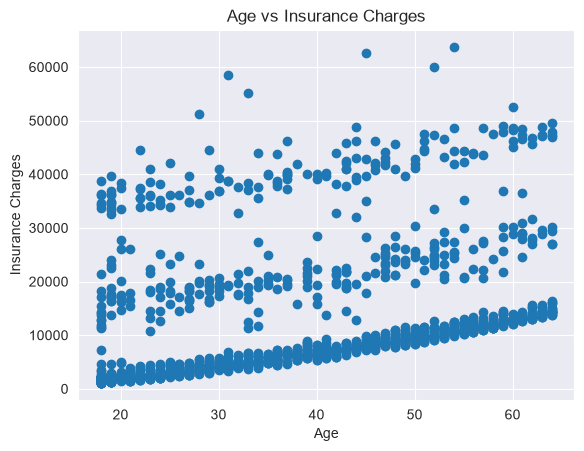

In [17]:
plt.scatter(data["age"], data["charges"])

plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Age vs Insurance Charges")

plt.show()

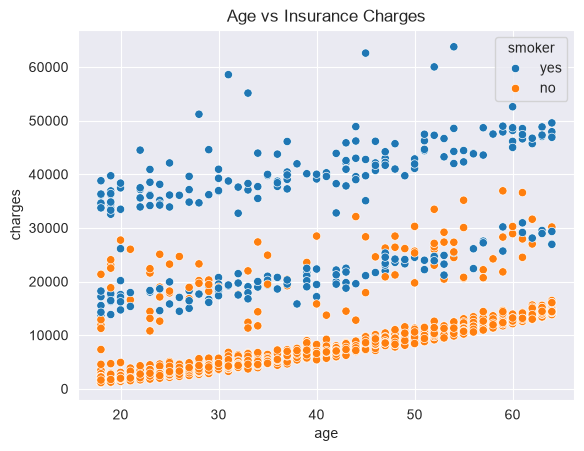

In [18]:
sns.scatterplot(
    data=data,
    x="age",
    y="charges",
    hue="smoker"
)

plt.title("Age vs Insurance Charges")
plt.show()

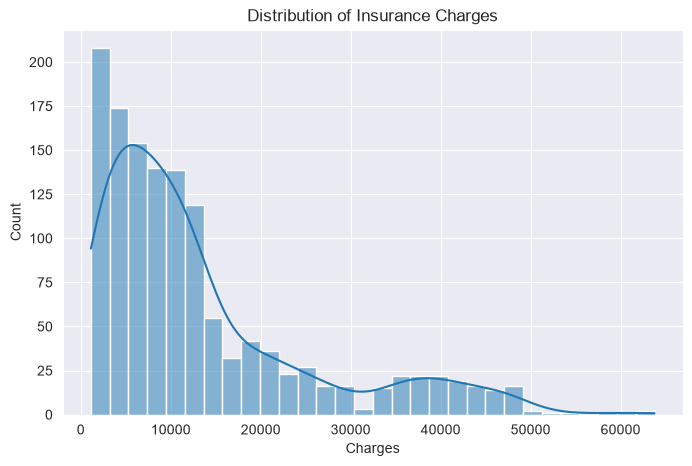

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(data["charges"], kde=True)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.show()

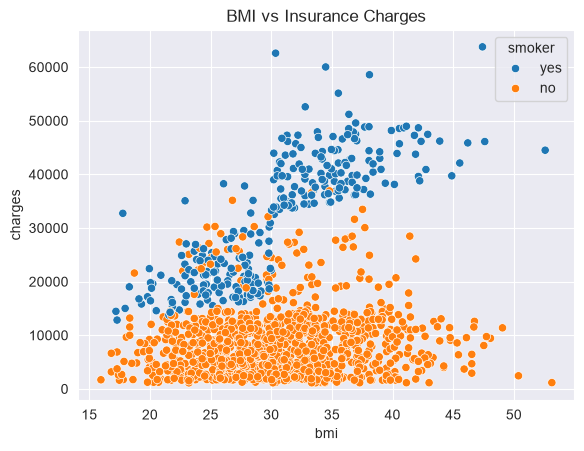

In [20]:
sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.title("BMI vs Insurance Charges")
plt.show()

In [21]:
data["charges"].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

#### 4.2 Analyse correlations

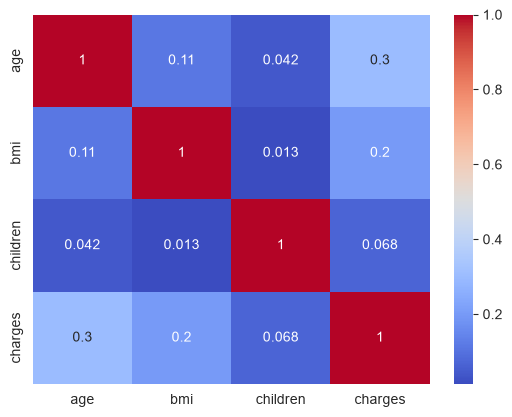

In [22]:
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [23]:
data.corr(numeric_only=True)["charges"].sort_values(ascending=False)

charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64

# 6. Feature Engineering

In [24]:
data_new = data.copy()

In [25]:
data_new["bmi_category"] = pd.cut(
    data_new["bmi"],
    bins=[0, 18.5, 25, 30, float("inf")],
    labels=["Underweight", "Normal", "Overweight", "Obese"])

In [26]:
data_new.groupby("bmi_category")["charges"].mean()

bmi_category
Underweight     8657.620652
Normal         10435.440719
Overweight     10997.803881
Obese          15560.926321
Name: charges, dtype: float64

In [27]:
data_new["age_group"] = pd.cut(
    data_new["age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["Child", "Young Adult", "Adult", "Middle Age", "Senior"])

In [28]:
data_new.groupby("age_group")["charges"].mean()

age_group
Child           7086.217556
Young Adult     9822.837599
Adult          12647.455654
Middle Age     16340.993846
Senior         21063.163398
Name: charges, dtype: float64

Encode Categorical Data

Change the sex values and smoker values to 0 and 1

In [29]:
data_new['sex'] = data_new['sex'].map({'female':1, 'male':0})
data_new['smoker'] = data_new['smoker'].map({'yes':1, 'no':0})

In [30]:
data_new["smoker_age"] = data_new["age"] * data_new["smoker"]

In [31]:
data_new["age_bmi"] = data_new["age"] * data_new["bmi"]

In [32]:
data_new["has_children"] = (data_new["children"] > 0).astype(int)

In [33]:
data_new.groupby("has_children")["charges"].mean()

has_children
0    12365.975602
1    13949.941093
Name: charges, dtype: float64

In [34]:
data_new.groupby("smoker")["charges"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
smoker,,,,,
0,1064,8434.268298,7345.40530,1121.8739,36910.60803
1,274,32050.231832,34456.34845,12829.4551,63770.42801


In [35]:
data_new.groupby("region")["charges"].agg(
    ["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
region,,,,,
northeast,324,13406.384516,10057.652025,1694.7964,58571.07448
northwest,325,12417.575374,8965.795750,1621.3402,60021.39897
southeast,364,14735.411438,9294.131950,1121.8739,63770.42801
southwest,325,12346.937377,8798.593000,1241.5650,52590.82939


In [36]:
data_new.groupby(["region", "smoker"])["charges"].mean()

region     smoker
northeast  0          9165.531672
           1         29673.536473
northwest  0          8556.463715
           1         30192.003182
southeast  0          8032.216309
           1         34844.996824
southwest  0          8019.284513
           1         32269.063494
Name: charges, dtype: float64

In [37]:
data_new.groupby(["smoker", "bmi_category"])["charges"].mean()

smoker  bmi_category
0       Underweight      5485.056800
        Normal           7734.650116
        Overweight       8226.088675
        Obese            8853.277294
1       Underweight     18809.824980
        Normal          19942.223641
        Overweight      22491.182935
        Obese           41692.808992
Name: charges, dtype: float64

In [38]:
data_new.groupby(["age_group", "smoker"])["charges"].mean()

age_group    smoker
Child        0          3215.162259
             1         25473.730221
Young Adult  0          4705.758286
             1         27825.092529
Adult        0          7246.170138
             1         31707.164316
Middle Age   0         12188.334036
             1         36451.732069
Senior       0         15366.613482
             1         38929.615407
Name: charges, dtype: float64

In [39]:
data_new.groupby(["age_group", "bmi_category"])["charges"].mean()

age_group    bmi_category
Child        Underweight      7262.125750
             Normal           4852.203298
             Overweight       6205.730951
             Obese            7956.435483
Young Adult  Underweight      5305.871122
             Normal           7175.013657
             Overweight       7459.844068
             Obese           12767.640778
Adult        Underweight     12526.415608
             Normal          11182.905033
             Overweight       9955.231655
             Obese           14925.761083
Middle Age   Underweight     11093.612112
             Normal          14011.797919
             Overweight      14420.321941
             Obese           17977.633602
Senior       Underweight              NaN
             Normal          17631.984615
             Overweight      21722.436498
             Obese           21484.359016
Name: charges, dtype: float64

In [40]:
data_new.groupby(
    ["age_group", "bmi_category", "smoker"]
)["charges"].mean()

age_group    bmi_category  smoker
Child        Underweight   0          1694.796400
                           1         12829.455100
             Normal        0          2815.878281
                           1         14015.665875
             Overweight    0          3269.083587
                           1         16973.437950
             Obese         0          3340.739676
                           1         35650.610325
Young Adult  Underweight   0          2612.945229
                           1         14731.111750
             Normal        0          4754.436643
                           1         17159.893837
             Overweight    0          4620.109862
                           1         18689.702065
             Obese         0          4848.851716
                           1         37076.481618
Adult        Underweight   0          5850.261838
                           1         25878.723150
             Normal        0          7851.477105
                

# 7. Visualise relationships

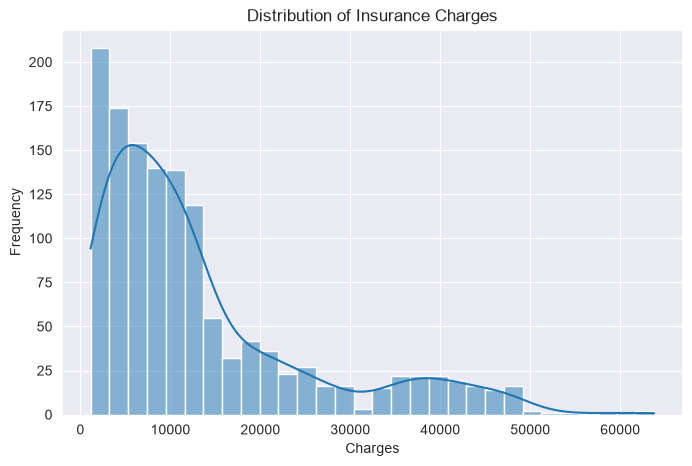

In [41]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data_new["charges"],
    bins=30,
    kde=True
)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

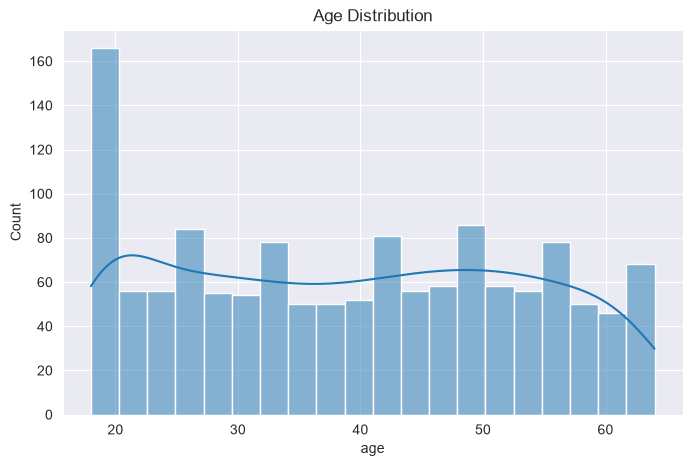

In [42]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data_new["age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

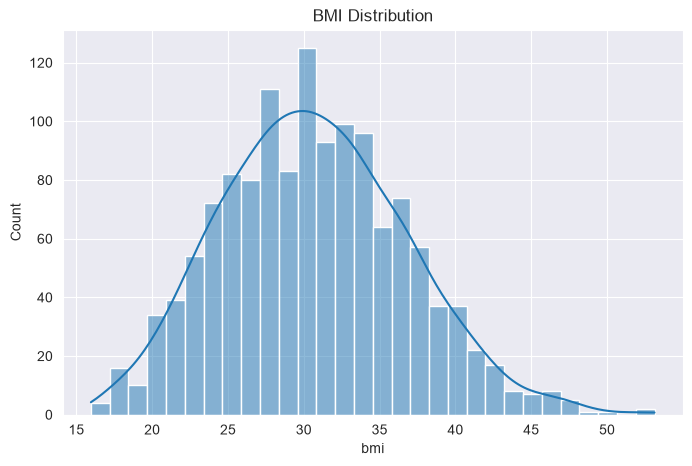

In [43]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data_new["bmi"],
    bins=30,
    kde=True
)

plt.title("BMI Distribution")

plt.show()

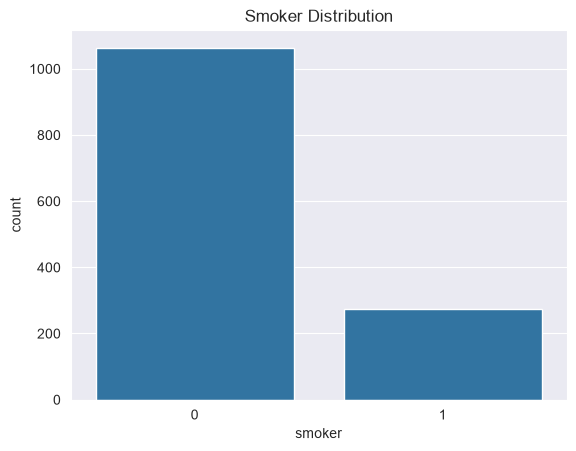

In [44]:
sns.countplot(
    data=data_new,
    x="smoker"
)

plt.title("Smoker Distribution")

plt.show()

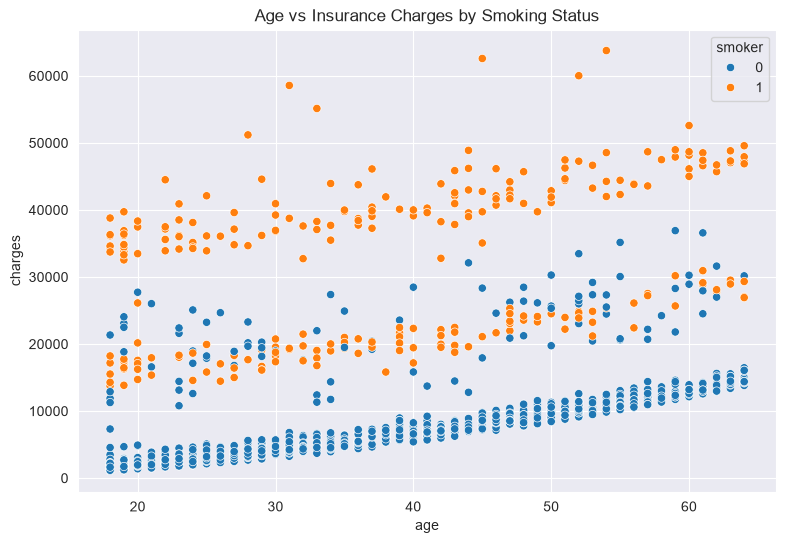

In [45]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=data_new,
    x="age",
    y="charges",
    hue="smoker"
)

plt.title("Age vs Insurance Charges by Smoking Status")

plt.show()

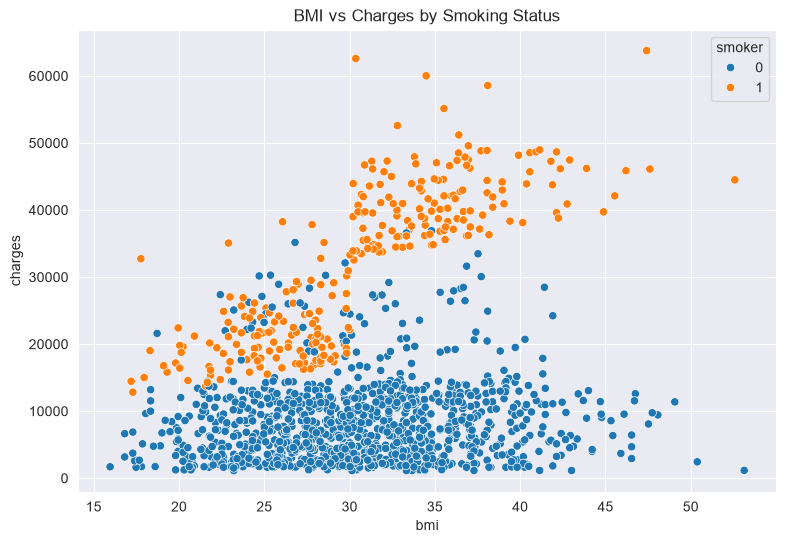

In [46]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=data_new,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.title("BMI vs Charges by Smoking Status")

plt.show()

In [47]:
data_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   age           1338 non-null   int64   
 1   sex           1338 non-null   int64   
 2   bmi           1338 non-null   float64 
 3   children      1338 non-null   int64   
 4   smoker        1338 non-null   int64   
 5   region        1338 non-null   object  
 6   charges       1338 non-null   float64 
 7   bmi_category  1338 non-null   category
 8   age_group     1338 non-null   category
 9   smoker_age    1338 non-null   int64   
 10  age_bmi       1338 non-null   float64 
 11  has_children  1338 non-null   int64   
dtypes: category(2), float64(3), int64(6), object(1)
memory usage: 107.7+ KB


In [48]:
print(data_new.corr(numeric_only=True)["charges"].sort_values(ascending = False))

charges         1.000000
smoker_age      0.789253
smoker          0.787251
age_bmi         0.334754
age             0.299008
bmi             0.198341
children        0.067998
has_children    0.064760
sex            -0.057292
Name: charges, dtype: float64


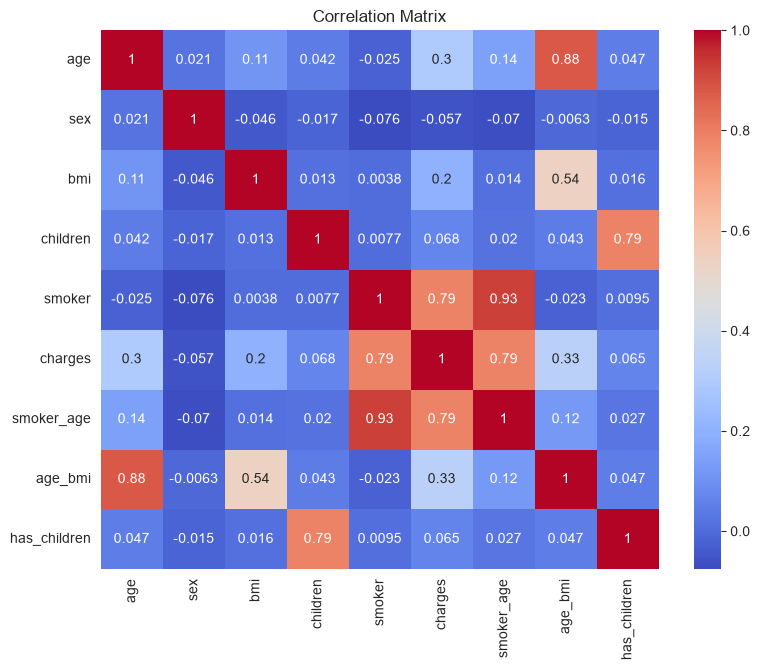

In [49]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    data_new.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Create a LinearRegression model

We split the data into 80% training data and 20% test data. We start with the data that has the new features we generated, then try again with the original data without new generated features.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [51]:
model_data = data_new.copy()

In [52]:
model_data = model_data.drop(columns = ['bmi_category', 'age_group'])

In [53]:
model_data = pd.get_dummies(
    model_data,
    columns=["region"],
    drop_first=True,
    dtype=int
)

In [54]:
y = model_data['charges']

In [55]:
x = model_data.drop(columns=["charges"])

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42)

In [57]:
linear_model = LinearRegression(fit_intercept=True)

In [58]:
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 289.26, 22.36, 393.32,...,-385.72,-705.78,-780.97]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['age','sex','bmi',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.322e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)


In [59]:
linear_predictions = linear_model.predict(X_test)

In [60]:
mae_linear = mean_absolute_error(y_test, linear_predictions)

In [61]:
rmse_linear = np.sqrt(mean_squared_error(y_test, linear_predictions))

In [62]:
r2_linear = r2_score(y_test, linear_predictions)

In [63]:
print("Linear Regression Score: ")
print("-----------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Score: 
-----------------
MAE : 4199.116479859246
RMSE: 5817.875154139917
R²  : 0.7819777914839058


In [64]:
#Let's use the original data and see. Start by encoding sex and smoker then create dummies for region

data["sex"] = data["sex"].map({"female": 0, "male": 1})
data["smoker"] = data["smoker"].map({"yes":1, "no":0})

data = pd.get_dummies(data, columns=["region"], drop_first=True, dtype=int)

In [65]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [66]:
y = data['charges']
X = data.drop(columns=['charges'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [67]:
linear_model_two = LinearRegression()

In [68]:
linear_model_two.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 256.98, -18.59, 337.09,...,-370.68,-657.86,-809.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','sex','bmi',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.193e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [69]:
linear_predictions = linear_model_two.predict(X_test)

In [70]:
mae_linear = mean_absolute_error(y_test, linear_predictions)
rmse_linear = np.sqrt(mean_squared_error(y_test, linear_predictions))
r2_linear = r2_score(y_test, linear_predictions)

In [71]:
print("Linear Regression Score: ")
print("-----------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Score: 
-----------------
MAE : 4181.194473753649
RMSE: 5796.284659276273
R²  : 0.7835929767120724
